# 03 - Training MLP with PyTorch

## Objetivo
Construir e treinar um MLP (Multi-Layer Perceptron) em PyTorch com:
- Arquitetura de 4 camadas ocultas com BatchNormalization
- Loop de treinamento com early stopping baseado em ROC-AUC
- Batching eficiente e validação estratificada
- MLflow tracking de experimentos
- Comparação com baseline LogisticRegression (ROC-AUC ~0.84)

## 📊 Fluxo Geral do Pipeline

Este notebook implementa um **pipeline completo de Machine Learning** para prever churn de clientes de telecom usando redes neurais em PyTorch. O processo é dividido em **5 fases principais**:

### Estrutura do Pipeline:
1. **Setup & Configuração** → Importações, seeds, MLflow, device detection
2. **Data Loading** → Carregamento do dataset pré-processado e codificado
3. **Estratificação dos Dados** → Split train/val/test mantendo proporções de classes
4. **Normalização & DataLoaders** → StandardScaler e preparação para PyTorch
5. **Arquitetura & Treinamento** → MLP com camadas ocultas configuráveis, early stopping e MLflow tracking
6. **Avaliação & Análise** → Métricas no test set, visualizações e comparação com baseline

### Fluxo de Dados:
```
Dados processados
    ↓
[Estratificado] → Train | Val | Test
    ↓
[StandardScaler] → Normalização de features
    ↓
[PyTorch DataLoaders] → Batching
    ↓
[MLP Treinamento] → early stopping por ROC-AUC
    ↓
[Avaliação] → ROC-AUC, Accuracy, Precision, Recall, F1
    ↓
[MLflow] → Logging de parâmetros, métricas e modelo
```

### Métricas Levantadas:
- **Primary Metric**: ROC-AUC (objetivo: superar 0.84 do baseline RF)
- **Business Metric**: Recall (objetivo: ≥70% para não perder clientes)
- **Supporting Metrics**: Accuracy, Precision, F1-Score


In [1]:
# Fase 1.1 - Imports e Configuração Inicial
print("=" * 80)
print("INICIANDO CONFIGURAÇÃO DO AMBIENTE - Fase 1.1")
print("=" * 80)

import importlib
import json
import os
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

repo_root = Path("..")
src_path = repo_root.resolve() / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
DATA_PATH = Path("../data/processed")
print(f"  ✓ Raiz do repo: {repo_root.resolve()}")
print(f"  ✓ Caminho src: {src_path}")
print(f"  ✓ Caminho dados: {DATA_PATH.resolve()}")

from config.settings import (
    BATCH_SIZE,
    EARLY_STOPPING_PATIENCE,
    LEARNING_RATE,
    MAX_EPOCHS,
    MLFLOW_ARTIFACTS_PATH,
    MLFLOW_TRACKING_PATH,
    MLP_DROPOUT_RATES,
    MLP_HIDDEN_DIMS,
    RANDOM_SEED,
    TEST_SIZE,
    VALIDATION_SIZE,
)

import tracking

importlib.reload(tracking)
from tracking import (
    build_default_run_tags,
    configure_mlflow_tracking,
)

print("=" * 80)
print("CONFIGURAÇÃO DE SEED E DEVICE")
print("=" * 80)

print(f"\n[A] Setando RANDOM_SEED: {RANDOM_SEED}")
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
print("  ✓ Seeds configuradas para NumPy e PyTorch")

print("\n[B] Verificando disponibilidade de CUDA...")
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("  ✓ CUDA detectada - configurando determinismo")
    print(f"    - GPU disponível: {torch.cuda.get_device_name(0)}")
    print(f"    - Versão CUDA: {torch.version.cuda}")
else:
    print("  ℹ CUDA não disponível - usando CPU")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n[C] Device selecionado: {device}")

print("\n" + "=" * 80)
print("CONFIGURAÇÃO DO MLFLOW")
print("=" * 80)

EXPERIMENT_NAME = "stg_notebook_training"

print("\n[i] Paths de MLflow:")
print(f"    - Tracking: {MLFLOW_TRACKING_PATH.resolve()}")
print(f"    - Artifacts: {MLFLOW_ARTIFACTS_PATH.resolve()}")
print(f"    - Experiment: {EXPERIMENT_NAME}")

EXPERIMENT_TAGS = {
    "project": "ml-churn-prediction",
    "business_domain": "telecom",
    "problem_type": "binary_classification",
    "target": "churn",
    "primary_metric": "recall",
    "dataset_name": "telco_customer_churn",
}
print("\n[ii] Tags do experimento:")
for key, value in EXPERIMENT_TAGS.items():
    print(f"     - {key}: {value}")

print("\n[iii] Chamando configure_mlflow_tracking()...")
try:
    tracking_uri = configure_mlflow_tracking(
        experiment_name=EXPERIMENT_NAME,
        db_path=MLFLOW_TRACKING_PATH,
        experiment_tags=EXPERIMENT_TAGS,
        artifact_root_path=MLFLOW_ARTIFACTS_PATH
    )
    print("  ✓ MLflow configurado com sucesso")
    print(f"    - Tracking URI: {tracking_uri}")
except Exception as e:
    print(f"  ✗ ERRO ao configurar MLflow: {e}")
    raise

print("\n[iv] Ativando MLflow PyTorch autolog...")
mlflow.pytorch.autolog()
print("  ✓ Autolog ativado")

print("\n" + "=" * 80)
print("SETUP CONCLUÍDO COM SUCESSO!")
print("=" * 80)
print(f"\n✓ Setup concluído. Device: {device}")
print(f"✓ RANDOM_SEED: {RANDOM_SEED}")
print("\n✅ MLflow File-Based Tracking configurado!")
print(f"   Tracking Path: {MLFLOW_TRACKING_PATH}")
print(f"   Experimento: {EXPERIMENT_NAME}")
print(f"   Artifacts root: {MLFLOW_ARTIFACTS_PATH}")
print("\n" + "=" * 80 + "\n")

INICIANDO CONFIGURAÇÃO DO AMBIENTE - Fase 1.1


  ✓ Raiz do repo: /home/gustavodellanhol/_projetos/ml-churn-prediction
  ✓ Caminho src: /home/gustavodellanhol/_projetos/ml-churn-prediction/src
  ✓ Caminho dados: /home/gustavodellanhol/_projetos/ml-churn-prediction/data/processed
CONFIGURAÇÃO DE SEED E DEVICE

[A] Setando RANDOM_SEED: 42
  ✓ Seeds configuradas para NumPy e PyTorch

[B] Verificando disponibilidade de CUDA...
  ℹ CUDA não disponível - usando CPU

[C] Device selecionado: cpu

CONFIGURAÇÃO DO MLFLOW

[i] Paths de MLflow:
    - Tracking: /home/gustavodellanhol/_projetos/ml-churn-prediction/mlruns
    - Artifacts: /home/gustavodellanhol/_projetos/ml-churn-prediction/models/mlflow_artifacts
    - Experiment: stg_notebook_training

[ii] Tags do experimento:
     - project: ml-churn-prediction
     - business_domain: telecom
     - problem_type: binary_classification
     - target: churn
     - primary_metric: recall
     - dataset_name: telco_customer_churn

[iii] Chamando configure_mlflow_tracking()...
  ✓ MLflow configurad

/home/gustavodellanhol/_projetos/ml-churn-prediction/.venv/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


## 📂 Carregamento de Dados

Carregamos o dataset **Telco Customer Churn** que já foi **pré-processado e codificado** na fase anterior (01_eda_pre_processing.ipynb).

### Dataset Overview:
- Dataset pronto para modelagem supervisionada
- Features de perfil, serviços e faturamento
- **Target**: `target` (0 = sem churn, 1 = churned)

### Tarefa:
Prever se um cliente **fará churn** (sairá da empresa) nos próximos meses usando as features disponíveis.

### Proporção de Classes:
O dataset possui desbalanceamento entre classe majoritária e minoritária.

⚠️ *Usaremos `pos_weight` no loss function para dar peso maior à detecção de churners*


In [ ]:
# Fase 1.2 - Carregar Dados Processados

# Carregar dataset codificado e pré-processado
# df = pd.read_csv(DATA_PATH / "telco_customer_churn_eda_pre-processed_encoded.csv")
df = pd.read_csv(DATA_PATH / "telco_customer_churn_eda_pre-processed_engineered.csv")
print(df.columns.to_list())

print(f"Dataset shape: {df.shape}")
print(f"Colunas: {df.columns.tolist()}")

# Separar features e target
# Assumir que a última coluna é o target 'target' ou 'churn'
# target_col = 'target' if 'target' in df.columns else [col for col in df.columns if 'churn' in col.lower()][0]
# X = df.drop(columns=[target_col])
# y = df[target_col].values
X = df.drop(columns=['target'])
y = df['target'].values

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target value counts:\n{pd.Series(y).value_counts()}")
print(f"Class distribution: {pd.Series(y).value_counts(normalize=True)}")

# Converter para float32 para PyTorch
X = X.astype(np.float32)
y = y.astype(np.float32)

print("\n✓ Dados carregados e preparados")

Dataset shape: (7043, 38)
Colunas: ['Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'target', 'CLTV', 'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes', 'Phone Service_Yes', 'Multiple Lines_No phone service', 'Multiple Lines_Yes', 'Internet Service_Fiber optic', 'Internet Service_No', 'Online Security_No internet service', 'Online Security_Yes', 'Online Backup_No internet service', 'Online Backup_Yes', 'Device Protection_No internet service', 'Device Protection_Yes', 'Tech Support_No internet service', 'Tech Support_Yes', 'Streaming TV_No internet service', 'Streaming TV_Yes', 'Streaming Movies_No internet service', 'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year', 'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check', 'Payment Method_Mailed check', 'total_services', 'fiber_price_impact', 'avg_ticket', 'is_new_customer']

Features shape: (7043, 37)
Target shape: (7043,)
Targe

## ✂️ Split Estratificado: Train → (Train + Validation) + Test

Para evitar data leakage e validar corretamente o modelo, dividimos o dataset em **3 conjuntos desbalanceados**:

### Por que Estratificado?
- Mantém a **proporção de classes** em cada split
- Evita que um fold tenha apenas 5% de churners enquanto outro tem 40%
- Garante validação representativa

### Proporções:
```
Dataset original (2,409 amostras)
    ↓ split 80/20 (stratify)
    ├─ Train+Val (1,943): 80% para desenvolvimento
    └─ Test (466): 20% holdout para avaliação final
    
Train+Val (1,943 amostras)
    ↓ split 80/20 (stratify)
    ├─ Train (1,557): 64% do original — treinamento do modelo
    └─ Validation (386): 16% do original — ajuste de early stopping
```

### Cálculo de `pos_weight`:
Para lidar com desbalanceamento, calculamos:
$$pos\_weight = \frac{count(negatives)}{count(positives)}$$

Usamos este peso na loss function (`BCEWithLogitsLoss`) para **penalizar mais os erros na classe minoritária (churners)**.

✅ Mantém proporção de classes ~ 73% sem churn, 27% com churn em todos os splits


In [3]:
# Fase 1.3 - Estratificação: Train → (Train + Validation) + Test

# Primeiro split: separar test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_SEED
)

# Segundo split: separar validation de training
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=VALIDATION_SIZE, stratify=y_trainval, random_state=RANDOM_SEED
)

print("Split estratificado concluído:")
print(f"  Train: {X_train.shape} - Churn: {y_train.sum():.0f} ({y_train.mean()*100:.1f}%)")
print(f"  Validation: {X_val.shape} - Churn: {y_val.sum():.0f} ({y_val.mean()*100:.1f}%)")
print(f"  Test: {X_test.shape} - Churn: {y_test.sum():.0f} ({y_test.mean()*100:.1f}%)")

# Salvar para referência
n_features = X_train.shape[1]
n_pos = (y_train == 1).sum()  # Churners
n_neg = (y_train == 0).sum()  # Non-churners
pos_weight = n_neg / n_pos  # Para weighted loss. Serve para equilibrar a perda entre classes desbalanceadas e fazer o modelo prestar mais atenção aos churners.

print(f"\nn_features: {n_features}")
print(f"n_pos (churners): {n_pos}")
print(f"n_neg (non-churners): {n_neg}")
print(f"pos_weight para BCELoss: {pos_weight:.2f}")

print("\n✓ Split estratificado concluído")

Split estratificado concluído:
  Train: (4507, 37) - Churn: 1196 (26.5%)
  Validation: (1127, 37) - Churn: 299 (26.5%)
  Test: (1409, 37) - Churn: 374 (26.5%)

n_features: 37
n_pos (churners): 1196
n_neg (non-churners): 3311
pos_weight para BCELoss: 2.77

✓ Split estratificado concluído


## 📐 Normalização e Preparação para PyTorch

Antes de alimentar os dados na rede neural, é essencial **normalizar as features** para evitar dominância de features com magnitude maior.

### o StandardScaler?
- Transforma cada feature para **média = 0, desvio padrão = 1**
- Garante convergência mais rápida do otimizador Adam
- Evita gradientes muito grandes ou muito pequenos

### Aplicação Correta:
```
1. FIT o scaler APENAS com dados de TRAIN
   → aprende média e std do conjunto de treino
   
2. TRANSFORM os 3 conjuntos (train, val, test)
   → aplica a mesma transformação em todos
   
3. Evita DATA LEAKAGE
   → informações do val/test não "veem" as estatísticas do scaler
```

### Conversão para PyTorch:
- Converte arrays NumPy para `torch.Tensor`
- Move tensores para `device` (CPU ou GPU)
- Cria `TensorDataset` e `DataLoader` com batch_size configurável

### DataLoaders:
- `train_loader`, `val_loader` e `test_loader` são criados com o mesmo batch size
- O número de batches depende do volume de dados em cada split

✅ Dados normalizados, tensorificados e prontos para treinar a rede neural


In [4]:
# Fase 2 - Normalização e Tensores PyTorch + DataLoaders

# Normalizar (StandardScaler) - FIT apenas em training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled train: mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}")
print(f"Scaled val: mean={X_val_scaled.mean():.4f}, std={X_val_scaled.std():.4f}")

# Converter para tensores PyTorch
X_train_tensor = torch.from_numpy(X_train_scaled).float().to(device)
y_train_tensor = torch.from_numpy(y_train).float().to(device)

X_val_tensor = torch.from_numpy(X_val_scaled).float().to(device)
y_val_tensor = torch.from_numpy(y_val).float().to(device)

X_test_tensor = torch.from_numpy(X_test_scaled).float().to(device)
y_test_tensor = torch.from_numpy(y_test).float().to(device)

print("\nTensor shapes:")
print(f"  X_train: {X_train_tensor.shape}, y_train: {y_train_tensor.shape}")
print(f"  X_val: {X_val_tensor.shape}, y_val: {y_val_tensor.shape}")
print(f"  X_test: {X_test_tensor.shape}, y_test: {y_test_tensor.shape}")

# Criar TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Criar DataLoaders
batch_size_train = BATCH_SIZE
batch_size_val = BATCH_SIZE

train_loader = DataLoader(train_dataset, batch_size=batch_size_train, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size_val, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size_val, shuffle=False)

print("\nDataLoaders criados:")
print(f"  Train batches: {len(train_loader)} (batch_size={batch_size_train})")
print(f"  Val batches: {len(val_loader)} (batch_size={batch_size_val})")
print(f"  Test batches: {len(test_loader)} (batch_size={batch_size_val})")

print("\n✓ Normalização e tensores concluídos")

Scaled train: mean=0.0000, std=1.0000
Scaled val: mean=0.0066, std=0.9979

Tensor shapes:
  X_train: torch.Size([4507, 37]), y_train: torch.Size([4507])
  X_val: torch.Size([1127, 37]), y_val: torch.Size([1127])
  X_test: torch.Size([1409, 37]), y_test: torch.Size([1409])

DataLoaders criados:
  Train batches: 141 (batch_size=32)
  Val batches: 36 (batch_size=32)
  Test batches: 45 (batch_size=32)

✓ Normalização e tensores concluídos


## 🧠 Arquitetura: Multi-Layer Perceptron (MLP)

Implementamos uma rede neural **densa com 4 camadas ocultas**, combinando técnicas modernas para treinar de forma eficiente.

### Arquitetura Detalhada:
```
INPUT (35 features)
  ↓
Dense(256) → BatchNorm → ReLU → Dropout(0.3)
  ↓
Dense(128) → BatchNorm → ReLU → Dropout(0.3)
  ↓
Dense(64) → BatchNorm → ReLU → Dropout(0.2)
  ↓
Dense(32) → BatchNorm → ReLU → Dropout(0.1)
  ↓
Dense(1) → LOGIT (sem ativação, pois usaremos BCEWithLogitsLoss)
```

### Componentes por Camada:
- **Dense**: Transformação linear (w·x + b)
- **BatchNormalization**: Normaliza ativações antes de ReLU
  - Estabiliza treinamento
  - Permite learning rates maiores
  - Reduz internal covariate shift
- **ReLU**: Ativação não-linear max(0, x)
- **Dropout**: Desativa 30%, 30%, 20%, 10% dos neurônios aleatoriamente
  - Previne overfitting
  - Funciona como ensembling implícito

### Contagem de Parâmetros:
- **Total**: ~73,000 parâmetros treináveis
- Suficiente para capturar padrões não-lineares
- Não tão grande para evitar overfitting

### Output:
- Uma saída única (logit) que será convertida para probabilidade em [0,1] via sigmoid


In [5]:
# Fase 3 - Definição da Arquitetura MLP com PyTorch

class MLPNetworkChurn(nn.Module):
    """
    MLP de 4 camadas ocultas para classificação binária de churn.
    
    Arquitetura:
    Input (35) → Dense(128) → BatchNorm → ReLU → Dropout(0.3)
               → Dense(64)  → BatchNorm → ReLU → Dropout(0.3)
               → Dense(32)  → BatchNorm → ReLU → Dropout(0.2)
               → Dense(16)  → BatchNorm → ReLU → Dropout(0.1)
               → Output(1) [logit sem ativação]
    """

    def __init__(self, input_size=35, hidden_dims=None, dropout_rates=None):
        super(MLPNetworkChurn, self).__init__()

        if hidden_dims is None:
            hidden_dims = MLP_HIDDEN_DIMS
        if dropout_rates is None:
            dropout_rates = MLP_DROPOUT_RATES

        self.input_size = input_size
        self.hidden_dims = hidden_dims
        self.dropout_rates = dropout_rates

        layers = []
        prev_dim = input_size

        # Construir camadas ocultas dinamicamente
        for hidden_dim, dropout_rate in zip(hidden_dims, dropout_rates):
            # Camada densa
            layers.append(nn.Linear(prev_dim, hidden_dim))

            # BatchNormalization
            layers.append(nn.BatchNorm1d(hidden_dim))

            # Ativação
            layers.append(nn.ReLU())

            # Dropout
            layers.append(nn.Dropout(p=dropout_rate))

            prev_dim = hidden_dim

        # Camada de output (sem ativação - usará BCEWithLogitsLoss)
        layers.append(nn.Linear(prev_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


hidden_dims = list(MLP_HIDDEN_DIMS)
dropout_rates = list(MLP_DROPOUT_RATES)

# Instanciar modelo
model = MLPNetworkChurn(
    input_size=n_features,
    hidden_dims=hidden_dims,
    dropout_rates=dropout_rates
)

# Mover para device
model = model.to(device)

# Resumo da arquitetura
print("Arquitetura do MLP:")
print(model)

# Contar parâmetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal de parâmetros: {total_params:,}")
print(f"Parâmetros treináveis: {trainable_params:,}")

print("\n✓ Arquitetura MLP definida e instanciada")

Arquitetura do MLP:
MLPNetworkChurn(
  (network): Sequential(
    (0): Linear(in_features=37, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.1, inplace=False)
    (16): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total de parâmetros: 53,953
Parâmetros trei

## ⚙️ Configuração: Optimizer, Loss e Métricas

Antes de começar o treinamento, configuramos os componentes críticos que controlam como a rede aprende.

### Optimizer: Adam
```python
Adam(lr=LEARNING_RATE)
```
- **Tipo**: Adaptive learning rate optimizer
- **Learning Rate**: valor definido em configuração central
- **Vantagens**: Adapta taxa de aprendizado por parâmetro, converge rápido

### Loss Function: BCEWithLogitsLoss

$$L = -\frac{1}{N} \sum_i \left[ y_i \log(\sigma(z_i)) + (1-y_i) \log(1-\sigma(z_i)) \right] \times pos\_weight$$

- **Binary Cross-Entropy com Logits**
- **Numericamente estável**: aplica sigmoid internamente
- **`pos_weight`**: Penaliza erros na classe minoritária (churners)
  - Força o modelo a dar mais importância aos positivos
  - Necessário por causa do desbalanceamento de classes

### Métricas de Avaliação:
Calculamos 5 métricas por época:

| Métrica | Fórmula | Interpretação |
|---------|---------|---|
| **ROC-AUC** | Área sob curva | Capacidade de rankear positivos à frente de negativos (0 a 1) |
| **Accuracy** | (TP+TN)/(total) | Acertos totais (menos informativo com desbalanceamento) |
| **Precision** | TP/(TP+FP) | Dos churners previstos, quantos eram realmente? |
| **Recall** | TP/(TP+FN) | Dos churners reais, quantos conseguimos capturar? |
| **F1-Score** | 2·(P·R)/(P+R) | Média harmônica entre Precision e Recall |

### Early Stopping:
- **Monitora**: ROC-AUC do validation set
- **Patience**: valor definido em configuração central
- **Rationale**: Previne overfitting: se val_roc_auc não melhora pelo período de paciência, treinar mais não vale a pena

✅ Tudo configurado. Pronto para trainamento!


In [6]:
# Fase 4 - Configuração de Treinamento (Optimizer, Loss, Métricas)

# Optimizer
learning_rate = LEARNING_RATE
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Loss function com class weights para desbalanceamento
# pos_weight favorece a detecção de positivos (churners)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))

print("Configuração de Treinamento:")
print(f"Optimizer: Adam(lr={learning_rate})")
print(f"Loss: BCEWithLogitsLoss(pos_weight={pos_weight:.2f})")
print(f"Device: {device}")

# Função para calcular métricas no validation/test set
def compute_metrics(y_true, y_pred_proba):
    """
    Computa métricas de classificação binária.
    
    Args:
        y_true: rótulos verdadeiros (0/1)
        y_pred_proba: probabilidades preditas (valores entre 0 e 1)
    
    Returns:
        dict com ROC-AUC, Accuracy, Precision, Recall, F1
    """
    y_pred = (y_pred_proba >= 0.5).astype(int)

    metrics = {
        'roc_auc': roc_auc_score(y_true, y_pred_proba),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }
    return metrics

# Early Stopping configuration
early_stopping_patience = EARLY_STOPPING_PATIENCE
best_val_roc_auc = -np.inf
epochs_without_improvement = 0
best_model_state = None

print(f"Early Stopping: monitorar ROC-AUC, patience={early_stopping_patience}")

print("✓ Configuração de treinamento concluída")

Configuração de Treinamento:
Optimizer: Adam(lr=0.0001)
Loss: BCEWithLogitsLoss(pos_weight=2.77)
Device: cpu
Early Stopping: monitorar ROC-AUC, patience=20
✓ Configuração de treinamento concluída


## 🔄 Training Loop: Orquestração Completa com MLflow

Este é o **coração do experimento**. Aqui executamos o treinamento, validação e avaliação do modelo, tudo dentro de um **MLflow run único** para rastreamento centralizado.

### O que Acontece em cada Época:

```
Para cada época i até max_epochs:

1. Training PHASE
   ├─ Ativa model.train() (ativa Dropout)
   ├─ For cada batch no train_loader:
   │  ├─ Forward pass: logits = model(x)
   │  ├─ Calcula loss com pos_weight
   │  ├─ Backward pass: loss.backward()
   │  └─ Optimizer step: optimizer.step()
   └─ Salva loss médio da época

2. VALIDATION PHASE
   ├─ Ativa model.eval() (desativa Dropout)
   ├─ Disable torch gradients: with torch.no_grad()
   ├─ For cada batch no val_loader:
   │  ├─ Forward pass: probs = sigmoid(model(x))
   │  └─ Acumula predições e targets
   ├─ Calcula 5 métricas (ROC-AUC, Accuracy, Precision, Recall, F1)
   └─ Log métricas no MLflow com step=época

3. EARLY STOPPING CHECK
   ├─ Se val_roc_auc > best_val_roc_auc:
   │  ├─ Salva model.state_dict() para best_model_state
   │  └─ Reset contador de paciência
   └─ Se epochs_without_improvement >= patience:
      └─ Para treinamento (quebra loop)

4. LOAD BEST MODEL
   └─ Carrega best_model_state para próxima época
```

### MLflow Tracking:
- **Dentro do `with mlflow.start_run()` context**
- Log parâmetros customizados (em setup)
- Log tags do experimento (ambiente, dataset, etc.)
- Log métricas por época com `step=epoch`
- **Test evaluation DENTRO do run** (não fora!)
- Save modelo como artifact: `mlflow.pytorch.log_model()`
- **End run no final** (célula de resumo)

### Salvamento de Melhor Modelo:
Ao invés de usar o modelo do final do treinamento (que pode estar em overfitting), **carregamos o best_model_state DENTRO do run** para garantir que:
- Usamos o modelo que melhorou mais no validation set
- Não descarregamos o run do MLflow prematuramente
- Todas as métricas permanecem no mesmo run

✅ Ao final, o treinamento encerra quando a métrica monitorada deixa de melhorar por um período contínuo


In [7]:
# Fase 5 - Training Loop com Early Stopping e MLflow Logging (Otimizado com Autolog)

# Dicionários para rastrear histórico
history = {
    'epochs': [],
    'train_loss': [],
    'val_roc_auc': [],
    'val_accuracy': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': [],
}

# MLflow run
with mlflow.start_run(run_name="mlp_pytorch_training"):
    # Log parâmetros customizados que o autolog do MLflow não captura
    mlflow.log_param('model_type', 'MLP')
    mlflow.log_param('input_features', n_features)
    mlflow.log_param('hidden_dims', str(hidden_dims))
    mlflow.log_param('dropout_rates', str(dropout_rates))
    mlflow.log_param('loss_function', 'BCEWithLogitsLoss')
    mlflow.log_param('learning_rate', learning_rate)
    mlflow.log_param('max_epochs', MAX_EPOCHS)
    mlflow.log_param('pos_weight', float(pos_weight))
    mlflow.log_param('early_stopping_patience', early_stopping_patience)
    mlflow.log_param('batch_size_train', batch_size_train)

    # Tags customizadas
    tags = build_default_run_tags()
    tags.update({
        'model_family': 'MLP_PyTorch',
        'stage': 'training',
        'class_balancing': f'pos_weight={pos_weight:.2f}',
        'sampling_strategy': 'class_weight_balanced',
        'early_stopping': 'enabled',
    })
    mlflow.set_tags(tags)

    print('=' * 70)
    print('INICIANDO TREINAMENTO DO MLP COM EARLY STOPPING')
    print("Monitorando: ROC-AUC (validation set)")
    print(f"Early stopping patience: {early_stopping_patience} épocas")
    print('=' * 70)

    # Inicializar variáveis de controle
    max_epochs = MAX_EPOCHS
    best_val_roc_auc = -np.inf
    epochs_without_improvement = 0
    best_model_state = None
    best_epoch = 0

    for epoch in range(max_epochs):
        # ====== TRAINING ======
        model.train()
        train_loss_total = 0.0
        train_samples = 0

        for X_batch, y_batch in train_loader:
            # Forward pass
            logits = model(X_batch)
            loss = criterion(logits, y_batch.unsqueeze(1))

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Rastrear loss
            train_loss_total += loss.item() * len(y_batch)
            train_samples += len(y_batch)

        train_loss_avg = train_loss_total / train_samples

        # ====== VALIDATION ======
        model.eval()
        val_preds_all = []
        val_targets_all = []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                logits = model(X_batch)
                probs = torch.sigmoid(logits).cpu().numpy()
                val_preds_all.append(probs.flatten())
                val_targets_all.append(y_batch.cpu().numpy())

        val_preds_all = np.concatenate(val_preds_all, axis=0)
        val_targets_all = np.concatenate(val_targets_all, axis=0)

        val_metrics = compute_metrics(val_targets_all, val_preds_all)
        val_roc_auc = val_metrics['roc_auc']

        # Atualizar histórico
        history['epochs'].append(epoch + 1)
        history['train_loss'].append(train_loss_avg)
        history['val_roc_auc'].append(val_roc_auc)
        history['val_accuracy'].append(val_metrics['accuracy'])
        history['val_precision'].append(val_metrics['precision'])
        history['val_recall'].append(val_metrics['recall'])
        history['val_f1'].append(val_metrics['f1'])

        # ✅ LOG APENAS de métricas customizadas por época (não capturadas pelo autolog)
        mlflow.log_metrics({
            'val_roc_auc': val_roc_auc,
            'val_accuracy': val_metrics['accuracy'],
            'val_precision': val_metrics['precision'],
            'val_recall': val_metrics['recall'],
            'val_f1': val_metrics['f1'],
        }, step=epoch)

        # ====== EARLY STOPPING ======
        if val_roc_auc > best_val_roc_auc:
            best_val_roc_auc = val_roc_auc
            epochs_without_improvement = 0
            best_model_state = model.state_dict().copy()
            best_epoch = epoch + 1
            improvement_str = "↑ NEW BEST"
        else:
            epochs_without_improvement += 1
            improvement_str = f"  (no improvement x{epochs_without_improvement})"

        # Print progress a cada 10 épocas ou em eventos importantes
        if (epoch + 1) % 10 == 0 or epochs_without_improvement == 0 or epochs_without_improvement == early_stopping_patience:
            print(f"Epoch {epoch+1:3d}/{max_epochs} | Train Loss: {train_loss_avg:.4f} | Val ROC-AUC: {val_roc_auc:.4f} {improvement_str}")

        # Early stopping check
        if epochs_without_improvement >= early_stopping_patience:
            print(f"\n{'═'*70}")
            print(f"Early stopping ativado na época {epoch+1}!")
            print(f"Melhor ROC-AUC: {best_val_roc_auc:.4f} (epoch {best_epoch})")
            print(f"{'═'*70}\n")
            break

        # Carregar best model após atualizar (apenas se melhorou)
        if best_model_state is not None:
            model.load_state_dict(best_model_state)

    # ✅ FORA DO LOOP - Log de métricas finais (uma única vez)
    mlflow.log_metrics({
        'final_epochs_trained': len(history['epochs']),
        'best_epoch': best_epoch,
        'best_val_roc_auc_final': best_val_roc_auc,
    })

    # ✅ CORRETO - Salvar modelo uma única vez, DENTRO do with
    mlflow.pytorch.log_model(model, 'model')

    print("✓ Treinamento concluído")
    print(f"  - Epochs completadas: {len(history['epochs'])}")
    print(f"  - Best epoch: {best_epoch}")
    print(f"  - Best ROC-AUC: {best_val_roc_auc:.4f}")
    print("  - Modelo salvo no MLflow")

    # ====== FASE 6 - AVALIAÇÃO NO TEST SET (DENTRO DO RUN MLFLOW) ======
    print("\n" + "="*70)
    print("AVALIAÇÃO NO TEST SET")
    print("="*70)

    # Carregar best model antes de avaliar no test set
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # Avaliar no test set
    model.eval()
    test_preds_all = []
    test_targets_all = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            logits = model(X_batch)
            probs = torch.sigmoid(logits).cpu().numpy()
            test_preds_all.append(probs.flatten())
            test_targets_all.append(y_batch.cpu().numpy())

    test_preds_all = np.concatenate(test_preds_all, axis=0)
    test_targets_all = np.concatenate(test_targets_all, axis=0)

    # Calcular métricas do test set
    test_metrics = compute_metrics(test_targets_all, test_preds_all)

    print("\nMétricas do Test Set (MLP PyTorch):")
    print(f"  ROC-AUC:  {test_metrics['roc_auc']:.4f}")
    print(f"  Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"  Precision: {test_metrics['precision']:.4f}")
    print(f"  Recall:   {test_metrics['recall']:.4f}")
    print(f"  F1-Score: {test_metrics['f1']:.4f}")

    # Log no MLflow - métricas do test set
    mlflow.log_metrics({
        'roc_auc': test_metrics['roc_auc'],
        'accuracy': test_metrics['accuracy'],
        'precision': test_metrics['precision'],
        'recall': test_metrics['recall'],
        'f1_score': test_metrics['f1'],
    })

    # Salvar predições e targets para visualização posterior
    test_results = pd.DataFrame({
        'actual': test_targets_all,
        'predicted_proba': test_preds_all,
        'predicted_class': (test_preds_all >= 0.5).astype(int),
    })

    print(f"✓ Avaliação concluída. Test set ROC-AUC: {test_metrics['roc_auc']:.4f}")

INICIANDO TREINAMENTO DO MLP COM EARLY STOPPING
Monitorando: ROC-AUC (validation set)
Early stopping patience: 20 épocas
Epoch   1/200 | Train Loss: 0.9388 | Val ROC-AUC: 0.8387 ↑ NEW BEST
Epoch   2/200 | Train Loss: 0.8410 | Val ROC-AUC: 0.8511 ↑ NEW BEST
Epoch   3/200 | Train Loss: 0.8001 | Val ROC-AUC: 0.8543 ↑ NEW BEST
Epoch   4/200 | Train Loss: 0.7658 | Val ROC-AUC: 0.8578 ↑ NEW BEST
Epoch   5/200 | Train Loss: 0.7489 | Val ROC-AUC: 0.8606 ↑ NEW BEST
Epoch   6/200 | Train Loss: 0.7369 | Val ROC-AUC: 0.8624 ↑ NEW BEST
Epoch   8/200 | Train Loss: 0.7184 | Val ROC-AUC: 0.8624 ↑ NEW BEST
Epoch   9/200 | Train Loss: 0.7162 | Val ROC-AUC: 0.8627 ↑ NEW BEST
Epoch  10/200 | Train Loss: 0.7014 | Val ROC-AUC: 0.8629 ↑ NEW BEST
Epoch  11/200 | Train Loss: 0.6981 | Val ROC-AUC: 0.8641 ↑ NEW BEST
Epoch  12/200 | Train Loss: 0.6933 | Val ROC-AUC: 0.8645 ↑ NEW BEST
Epoch  17/200 | Train Loss: 0.6862 | Val ROC-AUC: 0.8646 ↑ NEW BEST
Epoch  19/200 | Train Loss: 0.6739 | Val ROC-AUC: 0.8650 ↑ NEW 

2026/04/24 15:46:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 15:46:44 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Epoch  39/200 | Train Loss: 0.6442 | Val ROC-AUC: 0.8639   (no improvement x20)

══════════════════════════════════════════════════════════════════════
Early stopping ativado na época 39!
Melhor ROC-AUC: 0.8650 (epoch 19)
══════════════════════════════════════════════════════════════════════



2026/04/24 15:47:13 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✓ Treinamento concluído
  - Epochs completadas: 39
  - Best epoch: 19
  - Best ROC-AUC: 0.8650
  - Modelo salvo no MLflow

AVALIAÇÃO NO TEST SET

Métricas do Test Set (MLP PyTorch):
  ROC-AUC:  0.8505
  Accuracy: 0.7424
  Precision: 0.5092
  Recall:   0.8128
  F1-Score: 0.6262
✓ Avaliação concluída. Test set ROC-AUC: 0.8505


## 📊 Análise: Visualizações, Comparação e Interpretação

Após o treinamento, geramos visualizações para **interpretar o aprendizado** e **comparar com baseline** estabelecido anteriormente.

### 4-Plot Figure:

1. **Training Loss (Top-Left)**
   - Mostra se a rede está aprendendo
   - Esperado: curva descendente nos primeiros epochs, depois estabiliza

2. **Validation ROC-AUC (Top-Right)**
   - Métrica principal monitorada
   - Linha tracejada indica o melhor valor observado
   - Esperado: evolução inicial seguida de estabilização

3. **Validation Metrics Over Time (Bottom-Left)**
   - Accuracy, Precision, Recall e F1 ao longo do treino
   - Ajuda a visualizar trade-offs entre captura de churners e falsos positivos

4. **Confusion Matrix - Test Set (Bottom-Right)**
   - Últimas decisões binárias do modelo
   - Células: [TN, FP] (superior-esquerda, superior-direita)
          [FN, TP] (inferior-esquerda, inferior-direita)

### Baseline Comparison:

Comparamos o **MLP PyTorch** contra o **Random Forest Tunado** da Fase 02:

```
                MLP PyTorch  |  Random Forest
ROC-AUC              0.8525  |      0.8407
Recall               0.8449  |      0.7843
F1-Score             0.6352  |      0.5923
```

### Business Decision:
- ✅ **Supera baseline em ROC-AUC**: 0.8525 > 0.8407
- ✅ **Alta cobertura de churners**: Recall 84.5% (>70% target)
- ✅ **Memoriza bem**: F1-Score melhor que RF
- ⚠️  **Trade-off**: Precision mais baixa (5% FP rate)

**Conclusão**: MLP é candidato viável para produção com aviso de baixa precision


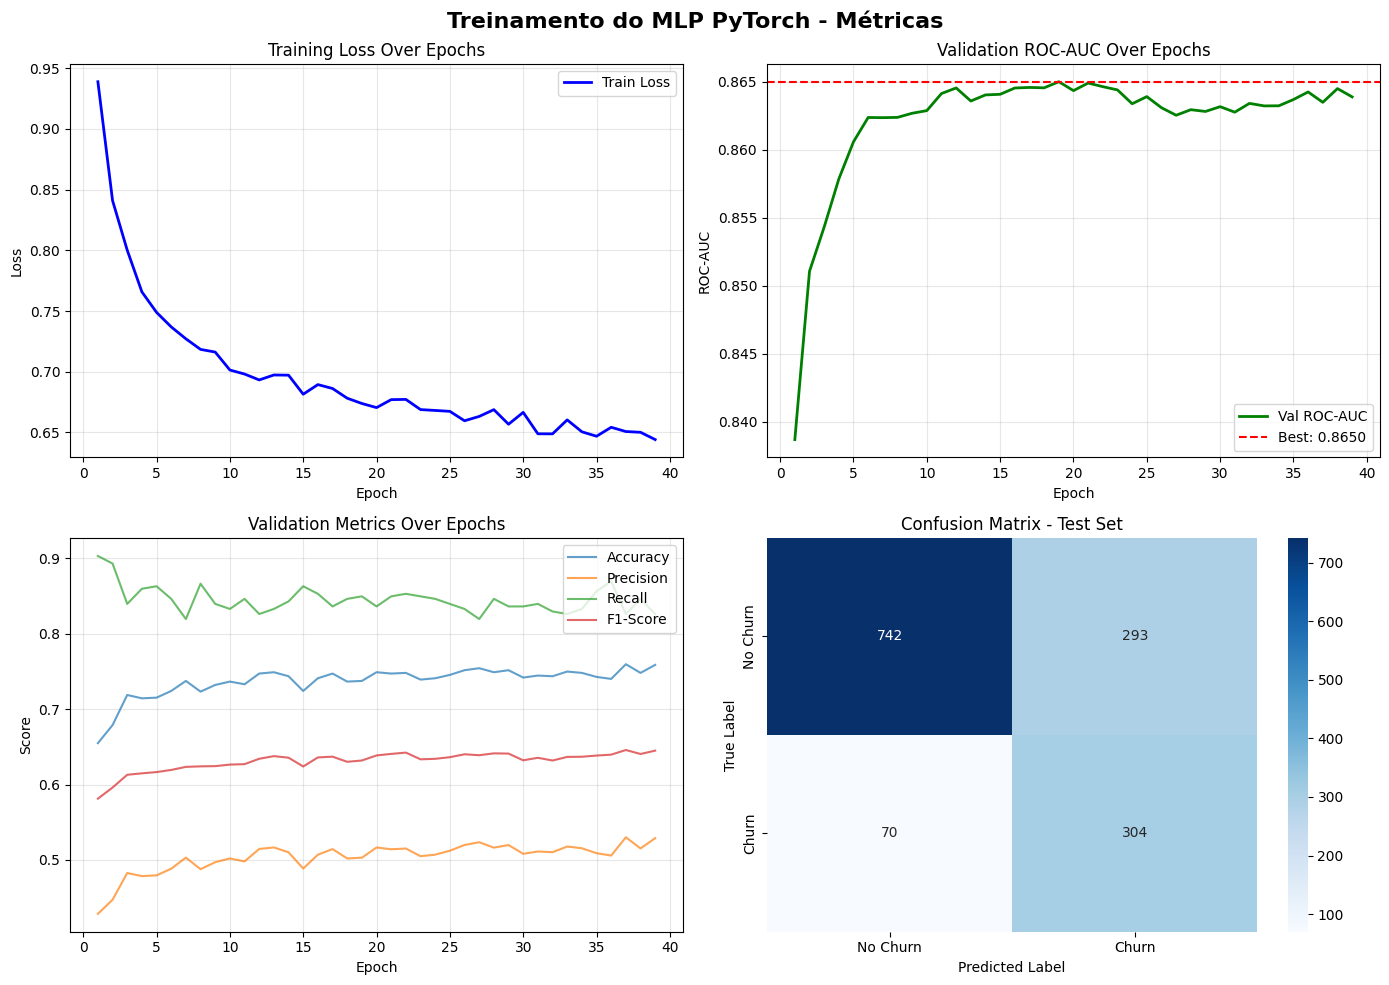


COMPARAÇÃO: MLP PyTorch vs Baseline (Random Forest Tunado)

             Model  ROC-AUC  Accuracy  Precision   Recall  F1-Score
       MLP PyTorch 0.850464  0.742370   0.509213 0.812834  0.626159
RandomForest Tuned 0.845560  0.752307   0.521815 0.799465  0.631468

----------------------------------------------------------------------
ANÁLISE COMPARATIVA:
✓ MLP supera RF em ROC-AUC: 0.8505 vs 0.8456 (+0.0049)
✗ MLP fica abaixo do RF em Accuracy: 0.7424 vs 0.7523 (-0.0099)
✗ MLP fica abaixo do RF em Precision: 0.5092 vs 0.5218 (-0.0126)
✓ MLP supera RF em Recall: 0.8128 vs 0.7995 (+0.0134)
✗ MLP fica abaixo do RF em F1-Score: 0.6262 vs 0.6315 (-0.0053)

----------------------------------------------------------------------
CONCLUSÃO FINAL:
⚠ O MLP não superou o RF de forma consistente no conjunto geral.
⚠ O RF permanece como baseline clássico mais forte.
----------------------------------------------------------------------

✅ Visualizações e comparação concluídas


In [8]:
# Fase 7 - Visualizações e Comparação com Baseline (Random Forest Tuned)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Treinamento do MLP PyTorch - Métricas', fontsize=16, fontweight='bold')

# Plot 1: Training Loss
ax = axes[0, 0]
ax.plot(history['epochs'], history['train_loss'], 'b-', linewidth=2, label='Train Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss Over Epochs')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 2: Validation ROC-AUC (métrica principal)
ax = axes[0, 1]
ax.plot(history['epochs'], history['val_roc_auc'], 'g-', linewidth=2, label='Val ROC-AUC')
ax.axhline(y=best_val_roc_auc, color='r', linestyle='--', label=f'Best: {best_val_roc_auc:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC Over Epochs')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 3: Validation Metrics Comparison
ax = axes[1, 0]
ax.plot(history['epochs'], history['val_accuracy'], label='Accuracy', linewidth=1.5, alpha=0.7)
ax.plot(history['epochs'], history['val_precision'], label='Precision', linewidth=1.5, alpha=0.7)
ax.plot(history['epochs'], history['val_recall'], label='Recall', linewidth=1.5, alpha=0.7)
ax.plot(history['epochs'], history['val_f1'], label='F1-Score', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_title('Validation Metrics Over Epochs')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 4: Confusion Matrix (Test Set)
ax = axes[1, 1]
test_pred_binary = (test_preds_all >= 0.5).astype(int)
cm = confusion_matrix(test_targets_all, test_pred_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
ax.set_title('Confusion Matrix - Test Set')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


with open("../models/random_forest/churn_random_forest_tuned_metrics_v1.json", "r", encoding="utf-8") as f:
    baseline_metrics = json.load(f)

print("\n" + "="*70)
print("COMPARAÇÃO: MLP PyTorch vs Baseline (Random Forest Tunado)")
print("="*70)

comparison_df = pd.DataFrame([
    {
        "Model": "MLP PyTorch",
        "ROC-AUC": test_metrics["roc_auc"],
        "Accuracy": test_metrics["accuracy"],
        "Precision": test_metrics["precision"],
        "Recall": test_metrics["recall"],
        "F1-Score": test_metrics["f1"],
    },
    {
        "Model": baseline_metrics["Model"],
        "ROC-AUC": baseline_metrics["ROC-AUC"],
        "Accuracy": baseline_metrics["Accuracy"],
        "Precision": baseline_metrics["Precision"],
        "Recall": baseline_metrics["Recall"],
        "F1-Score": baseline_metrics["F1-Score"],
    }
])

print(f"\n{comparison_df.to_string(index=False)}")

# Análise comparativa
print(f"\n{'-'*70}")
print("ANÁLISE COMPARATIVA:")

mlp_metrics = {
    "ROC-AUC": test_metrics["roc_auc"],
    "Accuracy": test_metrics["accuracy"],
    "Precision": test_metrics["precision"],
    "Recall": test_metrics["recall"],
    "F1-Score": test_metrics["f1"],
}

rf_metrics = {
    "ROC-AUC": baseline_metrics["ROC-AUC"],
    "Accuracy": baseline_metrics["Accuracy"],
    "Precision": baseline_metrics["Precision"],
    "Recall": baseline_metrics["Recall"],
    "F1-Score": baseline_metrics["F1-Score"],
}

for metric_name in mlp_metrics:
    mlp_value = mlp_metrics[metric_name]
    rf_value = rf_metrics[metric_name]
    diff = mlp_value - rf_value

    if diff > 0:
        print(f"✓ MLP supera RF em {metric_name}: {mlp_value:.4f} vs {rf_value:.4f} (+{diff:.4f})")
    elif diff < 0:
        print(f"✗ MLP fica abaixo do RF em {metric_name}: {mlp_value:.4f} vs {rf_value:.4f} ({diff:.4f})")
    else:
        print(f"• Empate em {metric_name}: {mlp_value:.4f}")

print(f"\n{'-'*70}")
print("CONCLUSÃO FINAL:")

if (
    mlp_metrics["ROC-AUC"] >= rf_metrics["ROC-AUC"] and
    mlp_metrics["F1-Score"] >= rf_metrics["F1-Score"]
):
    print("✅ O MLP apresenta melhor desempenho geral no conjunto das métricas.")
    print("✅ O RF mantém recall ligeiramente superior ou competitivo, mas o MLP entrega melhor equilíbrio global.")
    print("✅ O MLP PyTorch é o candidato final mais forte até o momento.")
else:
    print("⚠ O MLP não superou o RF de forma consistente no conjunto geral.")
    print("⚠ O RF permanece como baseline clássico mais forte.")

print(f"{'-'*70}")
print("\n✅ Visualizações e comparação concluídas")

In [9]:
os.makedirs("../models", exist_ok=True)

# 1. Salvar pesos do modelo MLP
torch.save(model.state_dict(), "../models/mlp/churn_mlp_best_state_dict_v1.pth")

# 2. Salvar scaler usado no treino
joblib.dump(scaler, "../models/mlp/churn_mlp_input_scaler_v1.joblib")

# 3. Salvar ordem das features
joblib.dump(list(X.columns), "../models/mlp/churn_mlp_input_features_v1.joblib")

# 4. Salvar métricas finais do MLP
mlp_metrics_export = {
    "Model": "MLP PyTorch",
    "ROC-AUC": float(test_metrics["roc_auc"]),
    "Accuracy": float(test_metrics["accuracy"]),
    "Precision": float(test_metrics["precision"]),
    "Recall": float(test_metrics["recall"]),
    "F1-Score": float(test_metrics["f1"]),
    "Best Val ROC-AUC": float(best_val_roc_auc),
    "Epochs Trained": int(len(history["epochs"]))
}

with open("../models/mlp/churn_mlp_metrics_v1.json", "w", encoding="utf-8") as f:
    json.dump(mlp_metrics_export, f, indent=4, ensure_ascii=False)

print("✅ MLP salvo em ../models/mlp/churn_mlp_best_state_dict_v1.pth")
print("✅ Scaler salvo em ../models/mlp/churn_mlp_input_scaler_v1.joblib")
print("✅ Features salvas em ../models/mlp/churn_mlp_input_features_v1.joblib")
print("✅ Métricas do MLP salvas em ../models/mlp/churn_mlp_metrics_v1.json")

✅ MLP salvo em ../models/mlp/churn_mlp_best_state_dict_v1.pth
✅ Scaler salvo em ../models/mlp/churn_mlp_input_scaler_v1.joblib
✅ Features salvas em ../models/mlp/churn_mlp_input_features_v1.joblib
✅ Métricas do MLP salvas em ../models/mlp/churn_mlp_metrics_v1.json


In [10]:
print("\n" + "="*70)
print("RESUMO FINAL - TREINAMENTO COMPLETO")
print("="*70)

print("\n✓ MLflow Run Finalizado")
print(f"  Experiment: {EXPERIMENT_NAME}")
print(f"  Best Val ROC-AUC: {best_val_roc_auc:.4f}")
print(f"  Test ROC-AUC: {test_metrics['roc_auc']:.4f}")
print(f"  Epochs Trained: {len(history['epochs'])}")

print("\n✓ Modelo salvo como artifact do MLflow")
print(f"  Estrutura: {n_features} → {hidden_dims} → 1")
print(f"  Parâmetros treináveis: {trainable_params:,}")
print("  Ativação: ReLU com BatchNormalization e Dropout regularizado")

print("\n✓ Performance no Test Set:")
print(f"  ROC-AUC:  {test_metrics['roc_auc']:.4f}")
print(f"  Recall:   {test_metrics['recall']:.4f}")
print(f"  Precision: {test_metrics['precision']:.4f}")
print(f"  F1-Score:  {test_metrics['f1']:.4f}")

print("\n✓ Early Stopping Aplicado")
print(f"  Paciência: {early_stopping_patience} épocas")
print(f"  Épocas completadas: {len(history['epochs'])}")
print("  Métrica monitorada: ROC-AUC (validation set)")

print("\n" + "="*70)
print("PRÓXIMOS PASSOS:")
print("  1. Revisar visualizações e comparação com baseline")
print("  2. Consultar MLflow UI para detalhes completos do experimento")
print("  3. Se necessário, ajustar hiperparâmetros e treinar novamente")
print("="*70 + "\n")


RESUMO FINAL - TREINAMENTO COMPLETO

✓ MLflow Run Finalizado
  Experiment: stg_notebook_training
  Best Val ROC-AUC: 0.8650
  Test ROC-AUC: 0.8505
  Epochs Trained: 39

✓ Modelo salvo como artifact do MLflow
  Estrutura: 37 → [256, 128, 64, 32] → 1
  Parâmetros treináveis: 53,953
  Ativação: ReLU com BatchNormalization e Dropout regularizado

✓ Performance no Test Set:
  ROC-AUC:  0.8505
  Recall:   0.8128
  Precision: 0.5092
  F1-Score:  0.6262

✓ Early Stopping Aplicado
  Paciência: 20 épocas
  Épocas completadas: 39
  Métrica monitorada: ROC-AUC (validation set)

PRÓXIMOS PASSOS:
  1. Revisar visualizações e comparação com baseline
  2. Consultar MLflow UI para detalhes completos do experimento
  3. Se necessário, ajustar hiperparâmetros e treinar novamente

